## 1. Environment Setup

This notebook builds a credit scoring model to predict applicant creditworthiness,
using the "Give Me Some Credit" dataset (income, debt, credit history, and related
financial features).

Before touching any data, I am setting up my working environment: core data-handling
libraries, the dataset downloader, and a consistent, deliberate visual style for
all charts used throughout this notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100 #rcParams: runtime configuration parameters.
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

print("Environment ready.")

Environment ready.


## 2. Dataset Acquisition

using the "Give Me Some Credit" dataset (Kaggle) — a real-world credit risk
dataset with ~150,000 applicant records, including income, debt ratio, credit line
history, and past-due history.

In [3]:
path = kagglehub.dataset_download("brycecf/give-me-some-credit-dataset")
print("Dataset downloaded to:", path)

import os
print("\nFiles available:")
for f in os.listdir(path):
    print(" -", f)

100%|██████████| 5.16M/5.16M [00:00<00:00, 137MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/brycecf/give-me-some-credit-dataset/versions/1

Files available:
 - sampleEntry.csv
 - cs-test.csv
 - Data Dictionary.xls
 - cs-training.csv


## 3. Loading the Data Dictionary & Training Data

Before inspecting the raw values, first we're loading the official Data Dictionary to understand what each column represents in real-world credit terms. then loading the labeled training dataset (`cs-training.csv`).


In [4]:
dict_path = os.path.join(path, "Data Dictionary.xls")
data_dict = pd.read_excel(dict_path)
print("Data Dictionary:")
display(data_dict)

train_path = os.path.join(path, "cs-training.csv")
df = pd.read_csv(train_path, index_col=0)

print("\nShape:", df.shape)
df.head()

Data Dictionary:


,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Variable Name,Description,Type
1,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
2,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
3,age,Age of borrower in years,integer
4,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
5,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
6,MonthlyIncome,Monthly income,real
7,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
8,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
9,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer



Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 4. Data Inspection — Structure, Types & Missing Values

examining the raw dataset itself: data
types per column, missing value counts, basic descriptive statistics, and the
balance of target variable before we decide how to handle them.

In [5]:
readable_names = {
    'SeriousDlqin2yrs': 'Became Seriously Delinquent',
    'RevolvingUtilizationOfUnsecuredLines': 'Credit Card Usage Ratio',
    'age': 'Age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Times 30-59 Days Late',
    'DebtRatio': 'Debt-to-Income Ratio',
    'MonthlyIncome': 'Monthly Income',
    'NumberOfOpenCreditLinesAndLoans': 'Open Credit Lines & Loans',
    'NumberOfTimes90DaysLate': 'Times 90+ Days Late',
    'NumberRealEstateLoansOrLines': 'Real Estate Loans/Lines',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Times 60-89 Days Late',
    'NumberOfDependents': 'Number of Dependents'
}

print("=== Data Types & Non-Null Counts ===")
df.info()

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_summary.index = missing_summary.index.map(readable_names)
print(missing_summary)

print("\n=== Descriptive Statistics ===")
desc = df.describe().T
desc.index = desc.index.map(readable_names)
display(desc)

print("\n=== Target Variable Balance (Became Seriously Delinquent) ===")
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(4) * 100, "% ")

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                  

,count,mean,std,min,25%,50%,75%,max
Became Seriously Delinquent,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
Credit Card Usage Ratio,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Times 30-59 Days Late,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
Debt-to-Income Ratio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
Monthly Income,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
Open Credit Lines & Loans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Times 90+ Days Late,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
Real Estate Loans/Lines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
Times 60-89 Days Late,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0



=== Target Variable Balance (Became Seriously Delinquent) ===
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64 % 


## 5. Investigating Data Quality Issues — Sentinel Values & Invalid Age

Before fixing anything, we investigate two suspicious patterns found during
inspection: the repeated "98" values in the late-payment columns, i think they are placeholder rather than a real count, and an applicant with Age = 0 which is not a  realistic value. We look at how many rows are affected and how they relate to the target before deciding on a fix.

In [6]:
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']

print("=== Value counts at/above 90 for each late-payment column ===")
for col in late_cols:
    high_vals = df[df[col] >= 90][col].value_counts()
    print(f"\n{readable_names[col]}:")
    print(high_vals)

sentinel_rows = df[(df['NumberOfTime30-59DaysPastDueNotWorse'] >= 90) |
                    (df['NumberOfTimes90DaysLate'] >= 90) |
                    (df['NumberOfTime60-89DaysPastDueNotWorse'] >= 90)]

print(f"\nTotal rows affected by the sentinel pattern: {len(sentinel_rows)}")
print(f"Percentage of dataset: {len(sentinel_rows) / len(df) * 100:.2f}%")

print(f"\nDelinquency rate WITHIN sentinel rows: {sentinel_rows['SeriousDlqin2yrs'].mean() * 100:.2f}%")
print(f"Delinquency rate OVERALL: {df['SeriousDlqin2yrs'].mean() * 100:.2f}%")

print("\n\n=== Age = 0 investigation ===")
age_zero = df[df['age'] == 0]
print(f"Number of rows with Age = 0: {len(age_zero)}")
display(age_zero)

=== Value counts at/above 90 for each late-payment column ===

Times 30-59 Days Late:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
Name: count, dtype: int64

Times 90+ Days Late:
NumberOfTimes90DaysLate
98    264
96      5
Name: count, dtype: int64

Times 60-89 Days Late:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
Name: count, dtype: int64

Total rows affected by the sentinel pattern: 269
Percentage of dataset: 0.18%

Delinquency rate WITHIN sentinel rows: 54.65%
Delinquency rate OVERALL: 6.68%


=== Age = 0 investigation ===
Number of rows with Age = 0: 1


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


## 6. Investigating Missing Values & Extreme Outliers
looked closer at the two remaining data quality issues: whether missing
values in Monthly Income and Number of Dependents relate meaningfully to the
target (informing our imputation strategy), and how extreme the outliers in
Credit Card Usage Ratio and Debt-to-Income Ratio actually are, using percentile
cutoffs rather than just min/max.

In [7]:
#Does missingness in MonthlyIncome relate to the target?
df['Income_Missing'] = df['MonthlyIncome'].isnull()
print("=== Delinquency rate by Monthly Income missingness ===")
print(df.groupby('Income_Missing')['SeriousDlqin2yrs'].mean() * 100)

#Does missingness in Dependents relate to the target?
df['Dependents_Missing'] = df['NumberOfDependents'].isnull()
print("\n=== Delinquency rate by Dependents missingness ===")
print(df.groupby('Dependents_Missing')['SeriousDlqin2yrs'].mean() * 100)

#Closer look at extreme values using percentiles
outlier_cols = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']

print("\n=== Percentile breakdown for outlier-prone columns ===")
for col in outlier_cols:
    print(f"\n{readable_names[col]}:")
    percentiles = df[col].quantile([0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 1.0])
    print(percentiles)

#How many rows exceed a "sane" threshold for each?
print(f"\nRows where Credit Card Usage Ratio > 2 (i.e. 200%): {(df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum()}")
print(f"Rows where Debt-to-Income Ratio > 5 (i.e. 500%): {(df['DebtRatio'] > 5).sum()}")

# Clean up temporary flag columns used only for this investigation
df.drop(columns=['Income_Missing', 'Dependents_Missing'], inplace=True)

=== Delinquency rate by Monthly Income missingness ===
Income_Missing
False    6.948590
True     5.613669
Name: SeriousDlqin2yrs, dtype: float64

=== Delinquency rate by Dependents missingness ===
Dependents_Missing
False    6.741012
True     4.561672
Name: SeriousDlqin2yrs, dtype: float64

=== Percentile breakdown for outlier-prone columns ===

Credit Card Usage Ratio:
0.500        0.154181
0.900        0.981278
0.950        1.000000
0.990        1.092956
0.995        1.366269
0.999     1571.006000
1.000    50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

Debt-to-Income Ratio:
0.500         0.366508
0.900      1267.000000
0.950      2449.000000
0.990      4979.040000
0.995      6186.010000
0.999     10613.074000
1.000    329664.000000
Name: DebtRatio, dtype: float64

Rows where Credit Card Usage Ratio > 2 (i.e. 200%): 371
Rows where Debt-to-Income Ratio > 5 (i.e. 500%): 29646


## 7. Investigating the Debt-to-Income Ratio Anomaly

The Debt-to-Income Ratio shows a large share of extreme, financially implausible
values — not just a small outlier tail. We investigate whether this connects to
low or missing Monthly Income (a known data quirk in this dataset, since the ratio
is calculated by dividing debt by income), before deciding how to handle it.

In [8]:
#Does extreme DebtRatio correlate with missing MonthlyIncome?
extreme_debt = df[df['DebtRatio'] > 5]  # our 500% threshold from before

print(f"Total rows with DebtRatio > 5: {len(extreme_debt)}")
print(f"Of those, rows with MISSING MonthlyIncome: {extreme_debt['MonthlyIncome'].isnull().sum()}")
print(f"Percentage: {extreme_debt['MonthlyIncome'].isnull().mean() * 100:.2f}%")

# Compare to the overall missing-income rate for context
print(f"\nOverall missing-income rate (whole dataset): {df['MonthlyIncome'].isnull().mean() * 100:.2f}%")

# For extreme-debt rows where income is NOT missing, what does income look like?
extreme_debt_income_present = extreme_debt[extreme_debt['MonthlyIncome'].notnull()]
print(f"\nAmong extreme-debt rows WITH income present, income stats:")
print(extreme_debt_income_present['MonthlyIncome'].describe())

Total rows with DebtRatio > 5: 29646
Of those, rows with MISSING MonthlyIncome: 27294
Percentage: 92.07%

Overall missing-income rate (whole dataset): 19.82%

Among extreme-debt rows WITH income present, income stats:
count     2352.000000
mean       297.769133
std       1586.502951
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max      33333.000000
Name: MonthlyIncome, dtype: float64


## 8. Data Cleaning

Based on our investigation, we now apply fixes for all five data quality issues:
missing Monthly Income, missing Number of Dependents, the sentinel 98/96 codes in
the late-payment columns, the single invalid Age = 0 row, and extreme outliers in
Credit Card Usage Ratio and Debt-to-Income Ratio. Each fix preserves useful signal
(via "was missing/flagged" indicator columns) rather than silently discarding
information.

Note: this version applies fixes to the full dataset purely to verify the logic
works as intended. The final, leakage-safe version — where statistics like the
median are learned only from training data — will be rebuilt inside a proper
scikit-learn Pipeline in the next phase.

In [9]:
# Add log-transform to our cleaning function
def clean_credit_data(data):
    data = data.copy()

    # Issue 1: Missing Monthly Income
    data['Income_Was_Missing'] = data['MonthlyIncome'].isnull().astype(int)
    income_median = data['MonthlyIncome'].median()
    data['MonthlyIncome'] = data['MonthlyIncome'].fillna(income_median)

    # Issue 2: Missing Number of Dependents
    data['Dependents_Was_Missing'] = data['NumberOfDependents'].isnull().astype(int)
    data['NumberOfDependents'] = data['NumberOfDependents'].fillna(0)

    # Issue 3: Sentinel 98/96 codes in late-payment columns
    late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
                 'NumberOfTimes90DaysLate',
                 'NumberOfTime60-89DaysPastDueNotWorse']

    data['Has_Sentinel_Code'] = (data[late_cols[0]] >= 90).astype(int)

    for col in late_cols:
        col_median = data.loc[data[col] < 90, col].median()
        data.loc[data[col] >= 90, col] = col_median

    # Issue 4: Age = 0
    age_median = data.loc[data['age'] > 0, 'age'].median()
    data.loc[data['age'] == 0, 'age'] = age_median

    # Issue 5: Extreme outliers
    # Cap RevolvingUtilization at 99th percentile (already well-behaved after this)
    cap_value = data['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)
    data['RevolvingUtilizationOfUnsecuredLines'] = data['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap_value)

    # Log-transform DebtRatio to address persistent right-skew (log1p handles 0 values safely)
    data['DebtRatio'] = np.log1p(data['DebtRatio'])

    return data


df_clean = clean_credit_data(df)

print("=== Verification ===")
print(f"Missing values remaining:\n{df_clean.isnull().sum().sum()} total\n")
print(f"Age = 0 remaining: {(df_clean['age'] == 0).sum()}")
print(f"Sentinel (>=90) values remaining: {(df_clean['NumberOfTimes90DaysLate'] >= 90).sum()}")
print(f"\nNew flag columns created: Income_Was_Missing, Dependents_Was_Missing, Has_Sentinel_Code")
print(f"\nRevised descriptive stats for previously extreme columns:")
display(df_clean[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']].describe())

=== Verification ===
Missing values remaining:
0 total

Age = 0 remaining: 0
Sentinel (>=90) values remaining: 0

New flag columns created: Income_Was_Missing, Dependents_Was_Missing, Has_Sentinel_Code

Revised descriptive stats for previously extreme columns:


,RevolvingUtilizationOfUnsecuredLines,DebtRatio
count,150000.000000,150000.000000
mean,0.320496,1.525174
std,0.352152,2.627237
min,0.000000,0.000000
25%,0.029867,0.161331
50%,0.154181,0.312258
75%,0.559046,0.625004
max,1.092956,12.705832


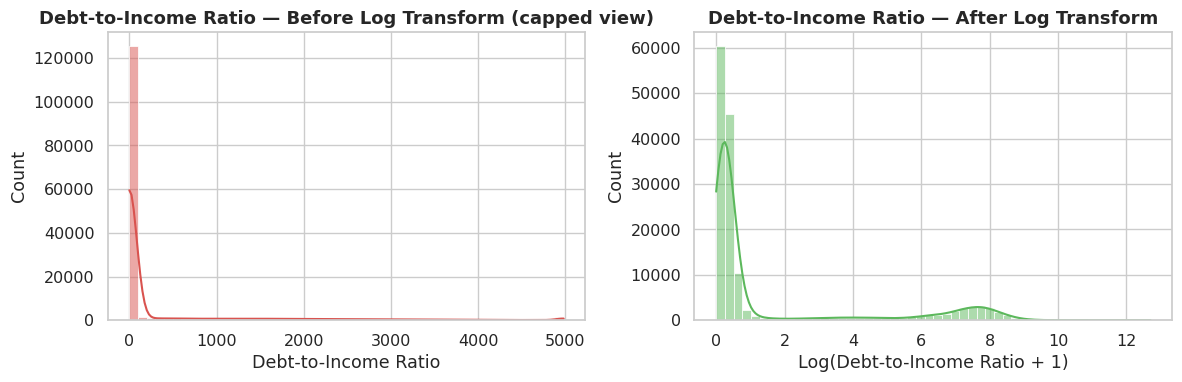

Before - mean: 316.549 | median: 0.367
After  - mean: 1.525 | median: 0.312


In [10]:
# Visual before/after comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['DebtRatio'].clip(upper=df['DebtRatio'].quantile(0.99)), bins=50, ax=axes[0], color='#d9534f', kde=True)
axes[0].set_title('Debt-to-Income Ratio — Before Log Transform (capped view)')
axes[0].set_xlabel('Debt-to-Income Ratio')

sns.histplot(df_clean['DebtRatio'], bins=50, ax=axes[1], color='#5cb85c', kde=True)
axes[1].set_title('Debt-to-Income Ratio — After Log Transform')
axes[1].set_xlabel('Log(Debt-to-Income Ratio + 1)')

plt.tight_layout()
plt.show()

print("Before - mean:", round(df['DebtRatio'].clip(upper=df['DebtRatio'].quantile(0.99)).mean(), 3),
      "| median:", round(df['DebtRatio'].clip(upper=df['DebtRatio'].quantile(0.99)).median(), 3))
print("After  - mean:", round(df_clean['DebtRatio'].mean(), 3),
      "| median:", round(df_clean['DebtRatio'].median(), 3))

## 10. Advanced Exploratory Data Analysis

With the data now cleaned (missing values handled, sentinel codes flagged,
outliers capped, skew corrected), we explore the relationships that actually
matter for creditworthiness prediction: how each feature relates to the target,
correlations between features, and the shape of our key financial variables —
using plain-language labels throughout.

/tmp/ipykernel_800/3559992818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='SeriousDlqin2yrs', data=df_clean, palette=['#5cb85c', '#d9534f'])
/tmp/ipykernel_800/3559992818.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good Standing', 'Became Delinquent'])


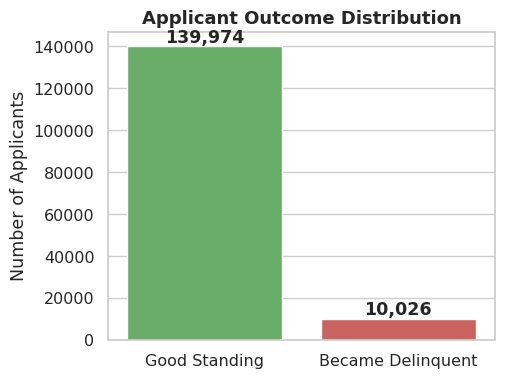

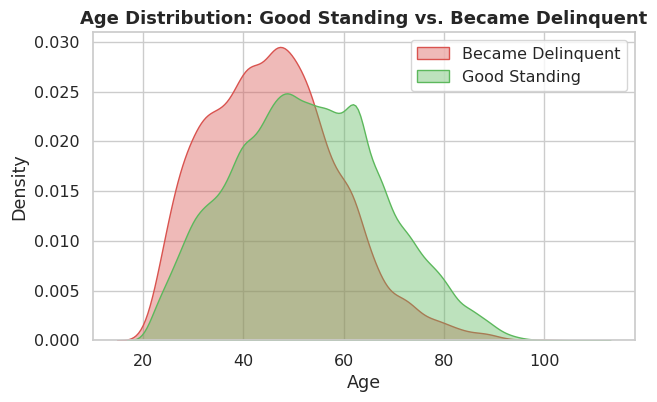

/tmp/ipykernel_800/3559992818.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='SeriousDlqin2yrs', y='MonthlyIncome', palette=['#5cb85c', '#d9534f'])


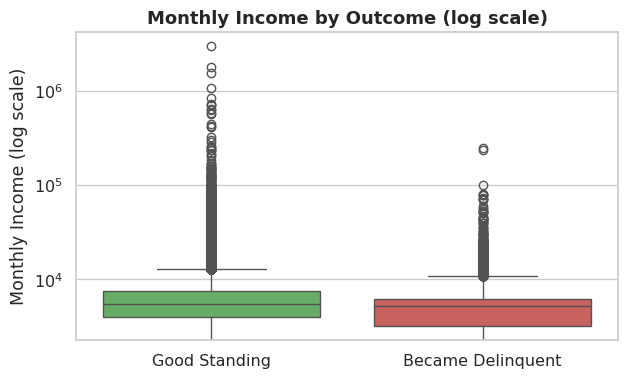

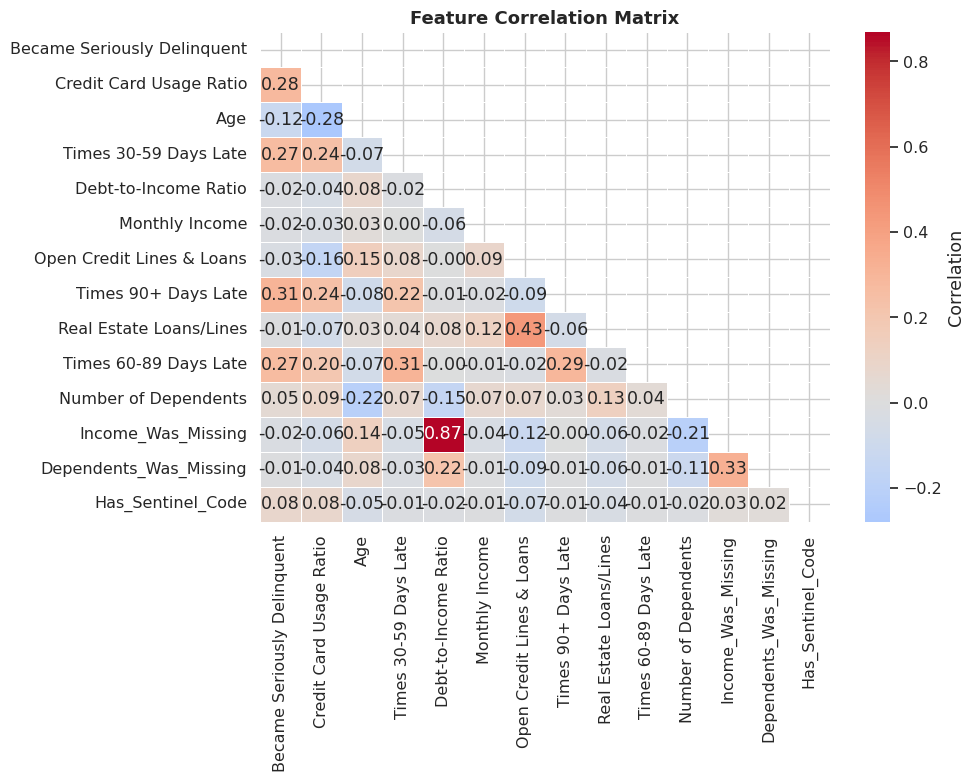

In [11]:
# Target balance, styled
plt.figure(figsize=(5,4))
ax = sns.countplot(x='SeriousDlqin2yrs', data=df_clean, palette=['#5cb85c', '#d9534f'])
ax.set_xticklabels(['Good Standing', 'Became Delinquent'])
plt.title('Applicant Outcome Distribution')
plt.xlabel('')
plt.ylabel('Number of Applicants')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.show()

# Age distribution by outcome
plt.figure(figsize=(7,4))
sns.kdeplot(data=df_clean, x='age', hue='SeriousDlqin2yrs', fill=True, common_norm=False,
            palette=['#5cb85c', '#d9534f'], alpha=0.4)
plt.title('Age Distribution: Good Standing vs. Became Delinquent')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(labels=['Became Delinquent', 'Good Standing'])
plt.show()

# Monthly Income by outcome (log scale, since income is right-skewed)
plt.figure(figsize=(7,4))
sns.boxplot(data=df_clean, x='SeriousDlqin2yrs', y='MonthlyIncome', palette=['#5cb85c', '#d9534f'])
plt.yscale('log')
plt.title('Monthly Income by Outcome (log scale)')
plt.xlabel('')
plt.xticks([0, 1], ['Good Standing', 'Became Delinquent'])
plt.ylabel('Monthly Income (log scale)')
plt.show()

# Correlation heatmap with readable names
plt.figure(figsize=(10, 8))
corr_df = df_clean.rename(columns=readable_names)
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

/tmp/ipykernel_800/3813820573.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(OUTCOME_LABELS)
/tmp/ipykernel_800/3813820573.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(OUTCOME_LABELS)
/tmp/ipykernel_800/3813820573.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,2].set_xticklabels(OUTCOME_LABELS)
/tmp/ipykernel_800/3813820573.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(OUTCOME_LABELS)
/tmp/ipykernel_800/3813820573.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

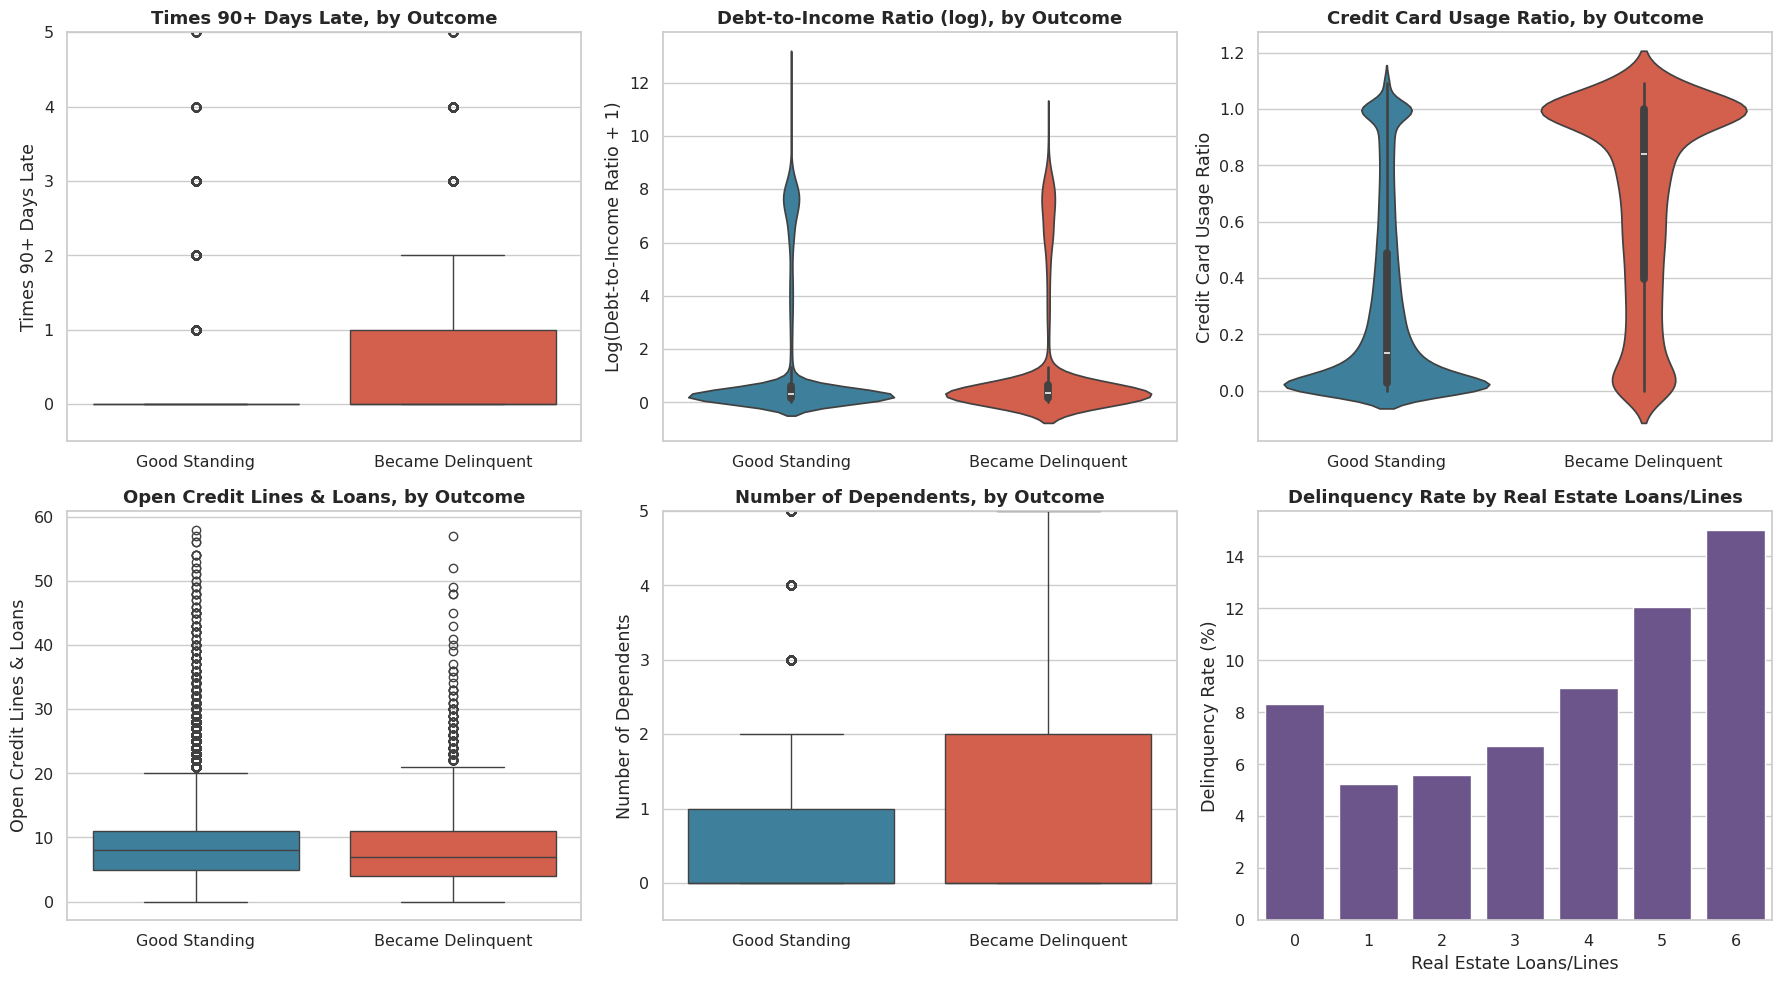

In [12]:
PALETTE = {0: '#2E86AB', 1: '#E94F37'}
PALETTE_LIST = [PALETTE[0], PALETTE[1]]
OUTCOME_LABELS = ['Good Standing', 'Became Delinquent']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Times 90+ Days Late vs target
sns.boxplot(data=df_clean, x='SeriousDlqin2yrs', y='NumberOfTimes90DaysLate',
            hue='SeriousDlqin2yrs', palette=PALETTE_LIST, legend=False, ax=axes[0,0])
axes[0,0].set_title('Times 90+ Days Late, by Outcome')
axes[0,0].set_xlabel('')
axes[0,0].set_xticklabels(OUTCOME_LABELS)
axes[0,0].set_ylabel('Times 90+ Days Late')
axes[0,0].set_ylim(-0.5, 5)

# 2. Debt-to-Income Ratio (log-transformed) vs target
sns.violinplot(data=df_clean, x='SeriousDlqin2yrs', y='DebtRatio',
               hue='SeriousDlqin2yrs', palette=PALETTE_LIST, legend=False, ax=axes[0,1])
axes[0,1].set_title('Debt-to-Income Ratio (log), by Outcome')
axes[0,1].set_xlabel('')
axes[0,1].set_xticklabels(OUTCOME_LABELS)
axes[0,1].set_ylabel('Log(Debt-to-Income Ratio + 1)')

# 3. Credit Card Usage Ratio vs target
sns.violinplot(data=df_clean, x='SeriousDlqin2yrs', y='RevolvingUtilizationOfUnsecuredLines',
               hue='SeriousDlqin2yrs', palette=PALETTE_LIST, legend=False, ax=axes[0,2])
axes[0,2].set_title('Credit Card Usage Ratio, by Outcome')
axes[0,2].set_xlabel('')
axes[0,2].set_xticklabels(OUTCOME_LABELS)
axes[0,2].set_ylabel('Credit Card Usage Ratio')

# 4. Open Credit Lines & Loans vs target
sns.boxplot(data=df_clean, x='SeriousDlqin2yrs', y='NumberOfOpenCreditLinesAndLoans',
            hue='SeriousDlqin2yrs', palette=PALETTE_LIST, legend=False, ax=axes[1,0])
axes[1,0].set_title('Open Credit Lines & Loans, by Outcome')
axes[1,0].set_xlabel('')
axes[1,0].set_xticklabels(OUTCOME_LABELS)
axes[1,0].set_ylabel('Open Credit Lines & Loans')

# 5. Number of Dependents vs target
sns.boxplot(data=df_clean, x='SeriousDlqin2yrs', y='NumberOfDependents',
            hue='SeriousDlqin2yrs', palette=PALETTE_LIST, legend=False, ax=axes[1,1])
axes[1,1].set_title('Number of Dependents, by Outcome')
axes[1,1].set_xlabel('')
axes[1,1].set_xticklabels(OUTCOME_LABELS)
axes[1,1].set_ylabel('Number of Dependents')
axes[1,1].set_ylim(-0.5, 5)

# 6. Delinquency RATE by number of real estate loans
real_estate_rates = df_clean.groupby('NumberRealEstateLoansOrLines')['SeriousDlqin2yrs'].mean() * 100
real_estate_rates = real_estate_rates[real_estate_rates.index <= 6]
sns.barplot(x=real_estate_rates.index, y=real_estate_rates.values, ax=axes[1,2], color='#6A4C93')
axes[1,2].set_title('Delinquency Rate by Real Estate Loans/Lines')
axes[1,2].set_xlabel('Real Estate Loans/Lines')
axes[1,2].set_ylabel('Delinquency Rate (%)')

plt.tight_layout()
plt.show()

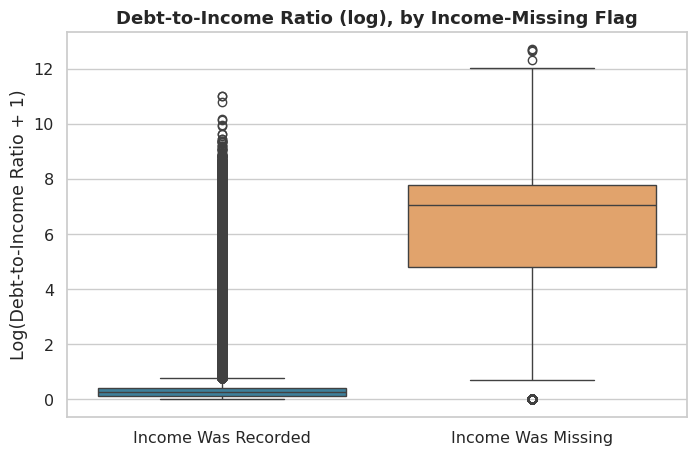

Correlation between Income_Was_Missing and DebtRatio: 0.869
Shared variance (correlation squared): 75.5%


In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Income_Was_Missing', y='DebtRatio',
            hue='Income_Was_Missing', palette=['#2E86AB', '#F4A259'], legend=False)
plt.title('Debt-to-Income Ratio (log), by Income-Missing Flag')
plt.xticks([0, 1], ['Income Was Recorded', 'Income Was Missing'])
plt.xlabel('')
plt.ylabel('Log(Debt-to-Income Ratio + 1)')
plt.show()

corr_val = df_clean['Income_Was_Missing'].corr(df_clean['DebtRatio'])
print(f"Correlation between Income_Was_Missing and DebtRatio: {corr_val:.3f}")
print(f"Shared variance (correlation squared): {corr_val**2 * 100:.1f}%")

## 13. Building the Preprocessing Pipeline

We now convert our cleaning logic into a proper scikit-learn `Pipeline`, so
preprocessing and modeling become one deployable object — fit only on training
data to avoid leakage, and reusable identically on test data or new applicants.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# Raw features/target split — pipeline will handle ALL cleaning internally
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train delinquency rate:", y_train.mean().round(4), "| Test:", y_test.mean().round(4))

Train shape: (120000, 10) | Test shape: (30000, 10)
Train delinquency rate: 0.0668 | Test: 0.0668


## 14. Custom Cleaning Transformer + Column Transformer + Full Pipeline
now we are going to package our five data-quality fixes into a custom scikit-learn transformer
a reusable class that learns statistics (medians, caps) only from training data in `.fit()`, then we apply them identically to any dataset in `.transform()`. We then combine it with a `ColumnTransformer` (scaling continuous features while leaving binary flags untouched) inside one final `Pipeline` object.

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

class CreditDataCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        X = X.copy()

        # Learn Income median (from non-missing training rows only)
        self.income_median_ = X['MonthlyIncome'].median()

        # Learn Age median (from valid, non-zero training rows only)
        self.age_median_ = X.loc[X['age'] > 0, 'age'].median()

        # Learn late-payment medians (from non-sentinel training rows only)
        self.late_cols_ = ['NumberOfTime30-59DaysPastDueNotWorse',
                            'NumberOfTimes90DaysLate',
                            'NumberOfTime60-89DaysPastDueNotWorse']
        self.late_medians_ = {
            col: X.loc[X[col] < 90, col].median() for col in self.late_cols_
        }

        # Learn the 99th percentile cap for Credit Card Usage Ratio
        self.usage_cap_ = X['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)

        return self  # scikit-learn convention: .fit() always returns self

    def transform(self, X):
        X = X.copy()

        # Issue 1: Missing Income
        X['Income_Was_Missing'] = X['MonthlyIncome'].isnull().astype(int)
        X['MonthlyIncome'] = X['MonthlyIncome'].fillna(self.income_median_)

        # Issue 2: Missing Dependents
        X['Dependents_Was_Missing'] = X['NumberOfDependents'].isnull().astype(int)
        X['NumberOfDependents'] = X['NumberOfDependents'].fillna(0)

        # Issue 3: Sentinel codes
        X['Has_Sentinel_Code'] = (X[self.late_cols_[0]] >= 90).astype(int)
        for col in self.late_cols_:
            X.loc[X[col] >= 90, col] = self.late_medians_[col]

        # Issue 4: Age = 0
        X.loc[X['age'] == 0, 'age'] = self.age_median_

        # Issue 5: Outliers
        X['RevolvingUtilizationOfUnsecuredLines'] = X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=self.usage_cap_)
        X['DebtRatio'] = np.log1p(X['DebtRatio'])

        return X


# Quick sanity check: fit on training data, transform both sets
cleaner = CreditDataCleaner()
cleaner.fit(X_train)

X_train_clean = cleaner.transform(X_train)
X_test_clean = cleaner.transform(X_test)

print("Learned income median (from TRAIN only):", cleaner.income_median_)
print("Learned age median (from TRAIN only):", cleaner.age_median_)
print("Learned usage cap (from TRAIN only):", round(cleaner.usage_cap_, 3))
print("\nMissing values in cleaned train set:", X_train_clean.isnull().sum().sum())
print("Missing values in cleaned test set:", X_test_clean.isnull().sum().sum())

Learned income median (from TRAIN only): 5390.0
Learned age median (from TRAIN only): 52.0
Learned usage cap (from TRAIN only): 1.094

Missing values in cleaned train set: 0
Missing values in cleaned test set: 0


## 15. Completing the Pipeline — Scaling & ColumnTransformer

Linear models (especially regularized ones like Ridge/Lasso, and distance-based
ones like SVM) are sensitive to feature scale — a feature like Monthly Income
(ranging into the thousands) would dominate a feature like Number of Dependents
(ranging 0-5) purely due to scale, not real importance. We add a `StandardScaler`
step, combined with our custom cleaner, into one complete `Pipeline`.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Full pipeline: clean -> scale
# (all 10 original features become 13 after cleaning adds 3 flag columns;
#  all 13 are numeric, so we scale everything together)
full_pipeline = Pipeline(steps=[
    ('cleaner', CreditDataCleaner()),
    ('scaler', StandardScaler())
])

# Fit on training data ONLY, transform both sets
X_train_processed = full_pipeline.fit_transform(X_train)
X_test_processed = full_pipeline.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# Confirm scaling worked: mean should be ~0, std should be ~1 for every column (on TRAIN)
print("\nTrain set — mean per column (should be ~0):")
print(np.round(X_train_processed.mean(axis=0), 3))
print("\nTrain set — std per column (should be ~1):")
print(np.round(X_train_processed.std(axis=0), 3))

Processed train shape: (120000, 13)
Processed test shape: (30000, 13)

Train set — mean per column (should be ~0):
[ 0.  0. -0. -0.  0.  0. -0. -0. -0.  0.  0. -0. -0.]

Train set — std per column (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 16. Model 1 — Logistic Regression (Baseline)

Our first model: standard Logistic Regression with no regularization penalty,
trained on the fully processed (cleaned + scaled) features via our pipeline.
This serves as our unregularized baseline — the reference point against which
Ridge, Lasso, and every other model will be compared.

In [17]:
from sklearn.linear_model import LogisticRegression

# Extend our pipeline with a final model step
logreg_pipeline = Pipeline(steps=[
    ('cleaner', CreditDataCleaner()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty=None, max_iter=1000, class_weight='balanced', random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

print("Logistic Regression trained.")
print("Number of coefficients learned:", logreg_pipeline.named_steps['model'].coef_.shape[1])

Logistic Regression trained.
Number of coefficients learned: 13


## 17. Evaluating Logistic Regression (Baseline)

We evaluate using metrics appropriate for imbalanced classification — accuracy
alone would be misleading here (predicting "no delinquency" for everyone would
already score ~93%). We use precision, recall, F1, ROC-AUC, and a confusion
matrix instead.

Accuracy: 0.8042
ROC-AUC:  0.8609

Classification Report:
                   precision    recall  f1-score   support

    Good Standing       0.98      0.81      0.89     27995
Became Delinquent       0.22      0.75      0.34      2005

         accuracy                           0.80     30000
        macro avg       0.60      0.78      0.61     30000
     weighted avg       0.93      0.80      0.85     30000



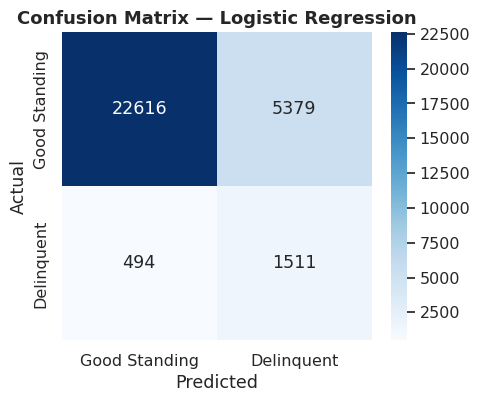

<Figure size 600x500 with 0 Axes>

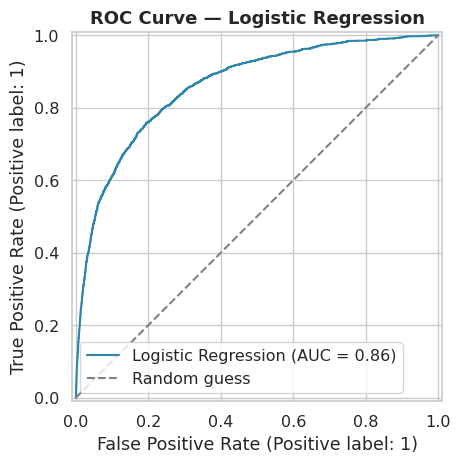

In [18]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay)

y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_proba_logreg)

print(f"Accuracy: {acc_logreg:.4f}")
print(f"ROC-AUC:  {auc_logreg:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=['Good Standing', 'Became Delinquent']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Standing', 'Delinquent'], yticklabels=['Good Standing', 'Delinquent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

# ROC Curve
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_proba_logreg, name='Logistic Regression', color='#2E86AB')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.show()

# Store for later comparison
results = {}
results['Logistic Regression'] = {'accuracy': acc_logreg, 'auc': auc_logreg,
                                   'y_pred': y_pred_logreg, 'y_proba': y_proba_logreg}

## 18. Model 2 — Ridge-Regularized Logistic Regression (L2 Penalty)

Same Logistic Regression model as before, but now with an L2 penalty added to
the loss function. This directly addresses the multicollinearity we found
earlier (Income_Was_Missing vs. Debt-to-Income Ratio) by discouraging any single
coefficient from growing too large.

In [19]:
ridge_pipeline = Pipeline(steps=[
    ('cleaner', CreditDataCleaner()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l2', C=1.0, max_iter=1000, class_weight='balanced', random_state=42))
])

ridge_pipeline.fit(X_train, y_train)

y_pred_ridge = ridge_pipeline.predict(X_test)
y_proba_ridge = ridge_pipeline.predict_proba(X_test)[:, 1]

acc_ridge = accuracy_score(y_test, y_pred_ridge)
auc_ridge = roc_auc_score(y_test, y_proba_ridge)

print(f"Accuracy: {acc_ridge:.4f}")
print(f"ROC-AUC:  {auc_ridge:.4f}\n")
print(classification_report(y_test, y_pred_ridge, target_names=['Good Standing', 'Became Delinquent']))

results['Ridge Logistic Regression'] = {'accuracy': acc_ridge, 'auc': auc_ridge,
                                          'y_pred': y_pred_ridge, 'y_proba': y_proba_ridge}

Accuracy: 0.8042
ROC-AUC:  0.8609

                   precision    recall  f1-score   support

    Good Standing       0.98      0.81      0.89     27995
Became Delinquent       0.22      0.75      0.34      2005

         accuracy                           0.80     30000
        macro avg       0.60      0.78      0.61     30000
     weighted avg       0.93      0.80      0.85     30000



## 18b. Investigating Why Ridge Matched the Baseline

With 120,000 training rows and only 13 features, the unregularized model already
has stable coefficients, so mild regularization (C=1.0) had little visible effect
on predictions. We compare coefficients directly, and test a much stronger
penalty to confirm regularization is working as expected.

In [20]:
# Compare coefficients: baseline vs Ridge (C=1.0)
feature_names_processed = X_train.columns.tolist() + ['Income_Was_Missing', 'Dependents_Was_Missing', 'Has_Sentinel_Code']
# Note: our cleaner adds 3 new columns, so let's get the ACTUAL final column order from the cleaner directly
sample_transformed = logreg_pipeline.named_steps['cleaner'].transform(X_train.head())
feature_names_processed = sample_transformed.columns.tolist()

coef_baseline = logreg_pipeline.named_steps['model'].coef_[0]
coef_ridge_c1 = ridge_pipeline.named_steps['model'].coef_[0]

coef_compare = pd.DataFrame({
    'Feature': feature_names_processed,
    'Baseline (no penalty)': coef_baseline,
    'Ridge (C=1.0)': coef_ridge_c1
}).sort_values('Baseline (no penalty)', key=abs, ascending=False)

print("Coefficient comparison:")
display(coef_compare)

# Now try MUCH stronger regularization to make the effect obvious
ridge_strong_pipeline = Pipeline(steps=[
    ('cleaner', CreditDataCleaner()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l2', C=0.01, max_iter=1000, class_weight='balanced', random_state=42))
])
ridge_strong_pipeline.fit(X_train, y_train)

coef_ridge_strong = ridge_strong_pipeline.named_steps['model'].coef_[0]
coef_compare['Ridge (C=0.01, strong)'] = coef_ridge_strong

y_pred_ridge_strong = ridge_strong_pipeline.predict(X_test)
y_proba_ridge_strong = ridge_strong_pipeline.predict_proba(X_test)[:, 1]
print(f"\nStrong Ridge (C=0.01) — Accuracy: {accuracy_score(y_test, y_pred_ridge_strong):.4f}, "
      f"ROC-AUC: {roc_auc_score(y_test, y_proba_ridge_strong):.4f}")

display(coef_compare)

Coefficient comparison:


,Feature,Baseline (no penalty),Ridge (C=1.0)
0,RevolvingUtilizationOfUnsecuredLines,0.728271,0.728239
6,NumberOfTimes90DaysLate,0.499309,0.499270
2,NumberOfTime30-59DaysPastDueNotWorse,0.400389,0.400376
8,NumberOfTime60-89DaysPastDueNotWorse,0.319368,0.319354
1,age,-0.282610,-0.282594
4,MonthlyIncome,-0.225245,-0.225144
5,NumberOfOpenCreditLinesAndLoans,0.173794,0.173764
7,NumberRealEstateLoansOrLines,0.144652,0.144628
3,DebtRatio,-0.136042,-0.135955
12,Has_Sentinel_Code,0.104408,0.104407



Strong Ridge (C=0.01) — Accuracy: 0.8042, ROC-AUC: 0.8608


,Feature,Baseline (no penalty),Ridge (C=1.0),"Ridge (C=0.01, strong)"
0,RevolvingUtilizationOfUnsecuredLines,0.728271,0.728239,0.725034
6,NumberOfTimes90DaysLate,0.499309,0.499270,-0.281036
2,NumberOfTime30-59DaysPastDueNotWorse,0.400389,0.400376,0.399063
8,NumberOfTime60-89DaysPastDueNotWorse,0.319368,0.319354,-0.127904
1,age,-0.282610,-0.282594,-0.215687
4,MonthlyIncome,-0.225245,-0.225144,0.170849
5,NumberOfOpenCreditLinesAndLoans,0.173794,0.173764,0.495446
7,NumberRealEstateLoansOrLines,0.144652,0.144628,0.142385
3,DebtRatio,-0.136042,-0.135955,0.318011
12,Has_Sentinel_Code,0.104408,0.104407,0.017282


## 19. Model 3 — Lasso-Regularized Logistic Regression (L1 Penalty)

Same Logistic Regression structure again, this time with an L1 penalty. Unlike
Ridge's smooth shrinkage, L1 regularization can push weak coefficients to
exactly zero — performing automatic feature selection.

In [21]:
lasso_pipeline = Pipeline(steps=[
    ('cleaner', CreditDataCleaner()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l1', solver='liblinear', C=1.0,
                                   max_iter=1000, class_weight='balanced', random_state=42))
])

lasso_pipeline.fit(X_train, y_train)

y_pred_lasso = lasso_pipeline.predict(X_test)
y_proba_lasso = lasso_pipeline.predict_proba(X_test)[:, 1]

acc_lasso = accuracy_score(y_test, y_pred_lasso)
auc_lasso = roc_auc_score(y_test, y_proba_lasso)

print(f"Accuracy: {acc_lasso:.4f}")
print(f"ROC-AUC:  {auc_lasso:.4f}\n")
print(classification_report(y_test, y_pred_lasso, target_names=['Good Standing', 'Became Delinquent']))

# Check which coefficients Lasso zeroed out
coef_lasso = lasso_pipeline.named_steps['model'].coef_[0]
coef_compare['Lasso (C=1.0)'] = coef_lasso

zeroed = coef_compare[coef_compare['Lasso (C=1.0)'] == 0]
print(f"\nFeatures zeroed out by Lasso: {len(zeroed)}")
if len(zeroed) > 0:
    print(zeroed[['Feature', 'Lasso (C=1.0)']])

results['Lasso Logistic Regression'] = {'accuracy': acc_lasso, 'auc': auc_lasso,
                                          'y_pred': y_pred_lasso, 'y_proba': y_proba_lasso}

Accuracy: 0.8041
ROC-AUC:  0.8609

                   precision    recall  f1-score   support

    Good Standing       0.98      0.81      0.89     27995
Became Delinquent       0.22      0.75      0.34      2005

         accuracy                           0.80     30000
        macro avg       0.60      0.78      0.61     30000
     weighted avg       0.93      0.80      0.85     30000


Features zeroed out by Lasso: 0


In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_pipeline = Pipeline(steps=[
    ('cleaner', CreditDataCleaner()),
    ('scaler', StandardScaler()),
    ('model', LinearDiscriminantAnalysis())
])

lda_pipeline.fit(X_train, y_train)

y_pred_lda = lda_pipeline.predict(X_test)
y_proba_lda = lda_pipeline.predict_proba(X_test)[:, 1]

acc_lda = accuracy_score(y_test, y_pred_lda)
auc_lda = roc_auc_score(y_test, y_proba_lda)

print(f"Accuracy: {acc_lda:.4f}")
print(f"ROC-AUC:  {auc_lda:.4f}\n")
print(classification_report(y_test, y_pred_lda, target_names=['Good Standing', 'Became Delinquent']))

results['LDA'] = {'accuracy': acc_lda, 'auc': auc_lda, 'y_pred': y_pred_lda, 'y_proba': y_proba_lda}

Accuracy: 0.9329
ROC-AUC:  0.8607

                   precision    recall  f1-score   support

    Good Standing       0.95      0.98      0.96     27995
Became Delinquent       0.50      0.31      0.38      2005

         accuracy                           0.93     30000
        macro avg       0.72      0.64      0.67     30000
     weighted avg       0.92      0.93      0.93     30000



## 21. Model 5 — Linear SVM

Our final linear model: a Support Vector Machine with a linear kernel. Unlike
the previous models, SVM doesn't naturally output probabilities — it needs an
extra calibration step to produce them, which we apply here.

In [23]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC doesn't support predict_proba natively, so we wrap it in CalibratedClassifierCV
# to get probability estimates (needed for ROC-AUC and consistency with our other models)
svm_pipeline = Pipeline(steps=[
    ('cleaner', CreditDataCleaner()),
    ('scaler', StandardScaler()),
    ('model', CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
        method='sigmoid', cv=3
    ))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

print(f"Accuracy: {acc_svm:.4f}")
print(f"ROC-AUC:  {auc_svm:.4f}\n")
print(classification_report(y_test, y_pred_svm, target_names=['Good Standing', 'Became Delinquent']))

results['Linear SVM'] = {'accuracy': acc_svm, 'auc': auc_svm, 'y_pred': y_pred_svm, 'y_proba': y_proba_svm}

Accuracy: 0.9373
ROC-AUC:  0.8577

                   precision    recall  f1-score   support

    Good Standing       0.94      0.99      0.97     27995
Became Delinquent       0.61      0.17      0.26      2005

         accuracy                           0.94     30000
        macro avg       0.78      0.58      0.61     30000
     weighted avg       0.92      0.94      0.92     30000



## 22. Hyperparameter Tuning (Ridge & Lasso) + Final Model Comparison

Using cross-validation to find the optimal regularization strength (C) for Ridge
and Lasso, then retraining both at their best value and comparing all 5 models
side-by-side on the untouched test set.

In [24]:
from sklearn.model_selection import GridSearchCV

C_range = [0.001, 0.01, 0.1, 1, 10, 100]

# Tune Ridge
ridge_grid = GridSearchCV(
    Pipeline([('cleaner', CreditDataCleaner()), ('scaler', StandardScaler()),
              ('model', LogisticRegression(penalty='l2', max_iter=1000, class_weight='balanced', random_state=42))]),
    param_grid={'model__C': C_range}, scoring='roc_auc', cv=3, n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
print("Best Ridge C:", ridge_grid.best_params_['model__C'], "| CV ROC-AUC:", round(ridge_grid.best_score_, 4))

# Tune Lasso
lasso_grid = GridSearchCV(
    Pipeline([('cleaner', CreditDataCleaner()), ('scaler', StandardScaler()),
              ('model', LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced', random_state=42))]),
    param_grid={'model__C': C_range}, scoring='roc_auc', cv=3, n_jobs=-1
)
lasso_grid.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_
print("Best Lasso C:", lasso_grid.best_params_['model__C'], "| CV ROC-AUC:", round(lasso_grid.best_score_, 4))

# --- Evaluate tuned versions on test set ---
for name, model in [('Ridge (tuned)', best_ridge), ('Lasso (tuned)', best_lasso)]:
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results[name] = {'accuracy': accuracy_score(y_test, pred), 'auc': roc_auc_score(y_test, proba),
                      'y_pred': pred, 'y_proba': proba}

# --- Final comparison table, ALL models ---
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'ROC-AUC': [results[m]['auc'] for m in results],
    'Recall (Delinquent)': [recall_score(y_test, results[m]['y_pred']) for m in results]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

display(comparison)

Best Ridge C: 10 | CV ROC-AUC: 0.8548
Best Lasso C: 10 | CV ROC-AUC: 0.8548


,Model,Accuracy,ROC-AUC,Recall (Delinquent)
0,Logistic Regression,0.804233,0.860895,0.753616
1,Ridge (tuned),0.804233,0.860895,0.753616
2,Ridge Logistic Regression,0.804233,0.860895,0.753616
3,Lasso (tuned),0.804167,0.860888,0.753616
4,Lasso Logistic Regression,0.804133,0.860887,0.753616
5,LDA,0.932933,0.860682,0.311222
6,Linear SVM,0.937300,0.857731,0.166085


## 23. Final Model Selection & Feature Importance

Based on ROC-AUC (best, tied with regularized variants), recall on the minority
class (best by a wide margin), and interpretability, we select plain Logistic
Regression as our production model. We revisit its coefficients as the final,
actionable interpretability summary.

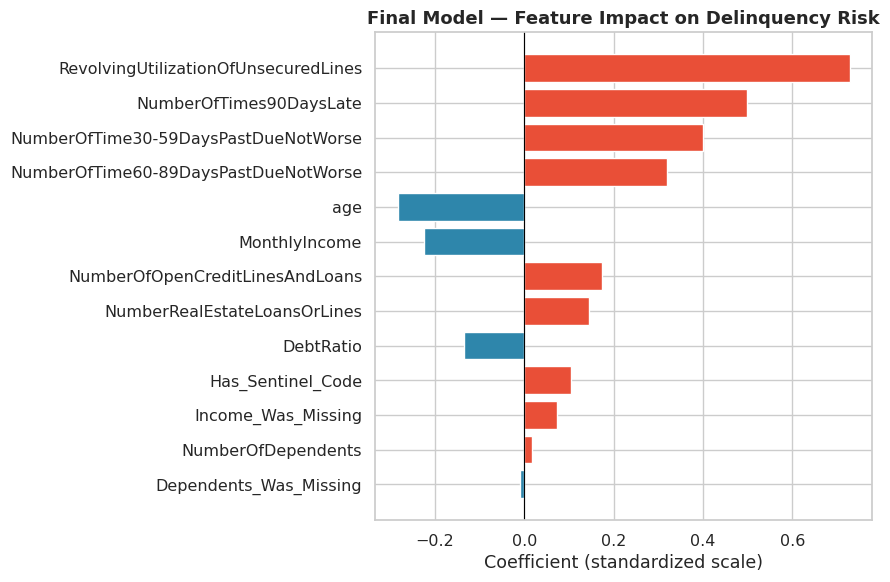

Selected production model: Logistic Regression (unregularized)
Test ROC-AUC: 0.8609
Test Recall (Delinquent class): 0.7536


In [25]:
final_model = logreg_pipeline  # our chosen production model

# Final, clean feature importance view — sorted by absolute impact
final_importance = coef_compare[['Feature', 'Baseline (no penalty)']].copy()
final_importance.columns = ['Feature', 'Coefficient']
final_importance['Direction'] = np.where(final_importance['Coefficient'] > 0, 'Increases Risk', 'Decreases Risk')
final_importance = final_importance.sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9,6))
colors = ['#E94F37' if d == 'Increases Risk' else '#2E86AB' for d in final_importance['Direction']]
plt.barh(final_importance['Feature'], final_importance['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Final Model — Feature Impact on Delinquency Risk')
plt.xlabel('Coefficient (standardized scale)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Selected production model: Logistic Regression (unregularized)")
print(f"Test ROC-AUC: {results['Logistic Regression']['auc']:.4f}")
print(f"Test Recall (Delinquent class): {recall_score(y_test, results['Logistic Regression']['y_pred']):.4f}")

## 24. Interactive Prediction Demo

A simple interface to score a new, hypothetical applicant using our final
trained model — enter their financial details and get a predicted
creditworthiness outcome plus the underlying probability.

=== Applicant A: stable profile ===
Predicted Risk Probability: 27.3%
Assessment: Good Standing (Low Risk)


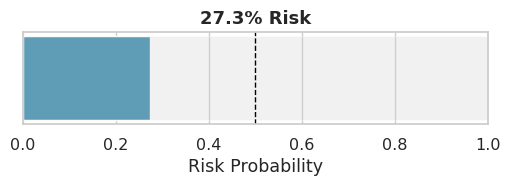


=== Applicant B: higher-risk profile ===
Predicted Risk Probability: 93.9%
Assessment: High Risk (Likely Delinquent)


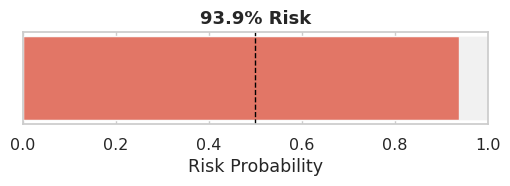

np.float64(0.9386280788059034)

In [32]:
def predict_applicant(monthly_income, age, debt_ratio, revolving_utilization,
                       times_30_59_late=0, times_60_89_late=0, times_90_late=0,
                       open_credit_lines=5, real_estate_loans=1, dependents=0):

    applicant = pd.DataFrame([{
        'RevolvingUtilizationOfUnsecuredLines': revolving_utilization,
        'age': age,
        'NumberOfTime30-59DaysPastDueNotWorse': times_30_59_late,
        'DebtRatio': debt_ratio,
        'MonthlyIncome': monthly_income,
        'NumberOfOpenCreditLinesAndLoans': open_credit_lines,
        'NumberOfTimes90DaysLate': times_90_late,
        'NumberRealEstateLoansOrLines': real_estate_loans,
        'NumberOfTime60-89DaysPastDueNotWorse': times_60_89_late,
        'NumberOfDependents': dependents
    }])

    proba = final_model.predict_proba(applicant)[0, 1]
    prediction = "High Risk (Likely Delinquent)" if proba >= 0.5 else "Good Standing (Low Risk)"

    print(f"Predicted Risk Probability: {proba*100:.1f}%")
    print(f"Assessment: {prediction}")

    plt.figure(figsize=(6, 1.2))
    plt.barh([0], [proba], color='#E94F37' if proba >= 0.5 else '#2E86AB')
    plt.barh([0], [1], color='lightgray', alpha=0.3)
    plt.xlim(0, 1)
    plt.axvline(0.5, color='black', linestyle='--', linewidth=1)
    plt.yticks([])
    plt.xlabel('Risk Probability')
    plt.title(f'{proba*100:.1f}% Risk')
    plt.show()

    return proba


# --- Example: a lower-risk profile ---
print("=== Applicant A: stable profile ===")
predict_applicant(monthly_income=6000, age=45, debt_ratio=0.3, revolving_utilization=0.2,
                   open_credit_lines=8, real_estate_loans=2, dependents=1)

print("\n=== Applicant B: higher-risk profile ===")
predict_applicant(monthly_income=1800, age=28, debt_ratio=0.9, revolving_utilization=0.95,
                   times_30_59_late=2, times_90_late=1, open_credit_lines=3,
                   real_estate_loans=0, dependents=2)